## Simple KNN exercise

We use KNN on the same spiral data set for multiclass classification.

KNN does remarkably well on this particular dataset, not just outperforming linear model but also dong better than a simple neural network.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [5]:
SEED = 1234

In [6]:
# Set seed for reproducibility
np.random.seed(SEED)
random.seed(SEED)

## Generate the data

We write a simple function to generate a spiral dataset; the dataset if very nonlinear even in just two dimesions, it would be very difficult for a linear classifier to classify the data well.

In [10]:
# A function to generate the a spiral dataset with 3 classes
# -----------------------------------------------------------
def generate_spiral_data(n_per_class=500, noise=0.05, random_seed=42):
    np.random.seed(random_seed)
    
    X_list = []
    y_list = []
    
    n_classes = 3
    for c in range(n_classes):
        # Angle offset for each class (120 degrees apart)
        angle_offset = c * (2 * np.pi / n_classes)
        
        # t goes from 0 to ~2.5π for a nice spiral
        t = np.linspace(0, 2.5 * np.pi, n_per_class)
        
        # Radius grows with t, normalized to stay within [-1, 1]
        r = t / (2.5 * np.pi)
        
        # Parametric spiral equations
        x1 = r * np.cos(t + angle_offset)
        x2 = r * np.sin(t + angle_offset)
        
        # Add noise
        x1 += np.random.randn(n_per_class) * noise
        x2 += np.random.randn(n_per_class) * noise
        
        X_list.append(np.column_stack([x1, x2]))
        y_list.extend([f"c{c+1}"] * n_per_class)
    
    X = np.vstack(X_list)
    y = np.array(y_list)
    
    # Shuffle
    idx = np.random.permutation(len(y))
    X, y = X[idx], y[idx]
    
    df = pd.DataFrame(X, columns=["X1", "X2"])
    df["color"] = y
    df = df.reset_index(drop=True)
    
    return df

In [11]:
# Generate the dataset
df = generate_spiral_data(n_per_class=500, noise=0.05)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nClass distribution:\n{df['color'].value_counts()}")

         X1        X2 color
0  0.309061  0.538668    c2
1 -0.003379  0.016664    c1
2  0.445510  0.836996    c1
3  0.459403 -0.156847    c2
4 -0.003708 -0.032028    c1

Shape: (1500, 3)

Class distribution:
color
c2    500
c1    500
c3    500
Name: count, dtype: int64


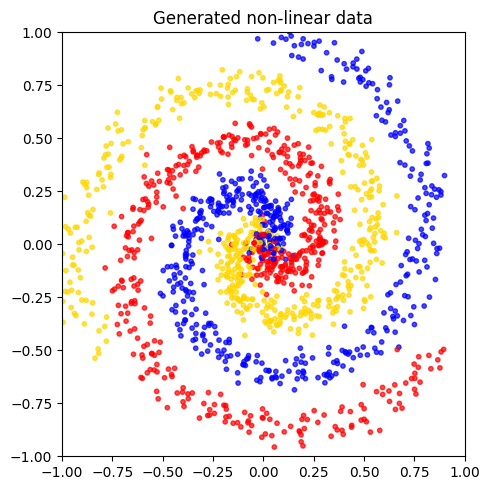

In [12]:
# Plot to verify
color_map = {"c1": "blue", "c2": "gold", "c3": "red"}
colors = df["color"].map(color_map)

plt.figure(figsize=(5, 5))
plt.scatter(df["X1"], df["X2"], c=colors, s=10, alpha=0.7)
plt.title("Generated non-linear data")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

# Save to CSV
# df.to_csv("spiral_data.csv", index=True)
# print("\nSaved to spiral_data.csv")

In [14]:
# We pull out Matrices and vectors as nd_arrays for model training
# also Print Data shapes

X = df[["X1", "X2"]].values
y = df["color"].values
print ("X: ", np.shape(X))
print ("y: ", np.shape(y))

X:  (1500, 2)
y:  (1500,)


## Split the data

We create training and validation data sets as well as a final test set

In [15]:
import collections
from sklearn.model_selection import train_test_split

In [16]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

In [17]:
# Helper fuction to create the train validation test split
#  use two successive applications of train_test_split from sklearn.model_selection

def train_val_test_split(X, y, train_size):
    """Split dataset into data splits."""
    X_train, X_, y_train, y_ = train_test_split(X, y, train_size=TRAIN_SIZE, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_, y_, train_size=0.5, stratify=y_)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [18]:
# Create data splits
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X=X, y=y, train_size=TRAIN_SIZE)
print (f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print (f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print (f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print (f"Sample point: {X_train[0]} → {y_train[0]}")

X_train: (1050, 2), y_train: (1050,)
X_val: (225, 2), y_val: (225,)
X_test: (225, 2), y_test: (225,)
Sample point: [-0.00262302 -0.00616305] → c3


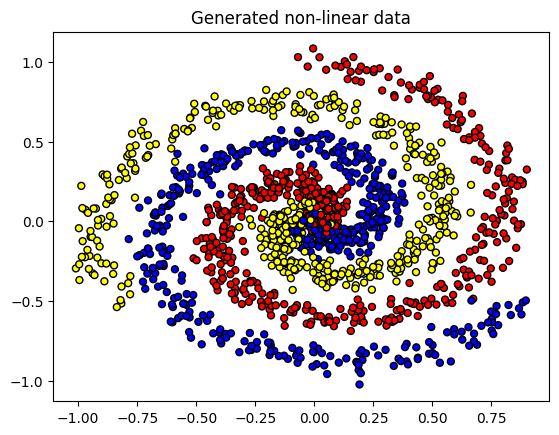

In [19]:
# Visualize data
plt.title("Generated non-linear data")
colors = {"c1": "red", "c2": "yellow", "c3": "blue"}
plt.scatter(X[:, 0], X[:, 1], c=[colors[_y] for _y in y], edgecolors="k", s=25)
plt.show()

## Label Encoding

We use a patter of fitting the label encoder on the Train data set and then use it to score all the other data sets to avoid any peeking at the validation and test sets. We have also used stratification to ensure that all the label values are equally represented in all the datasets.

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
# Output vectorizer
#  The label encoder can be use to both encode and decode our labels 
#   we will fit it on the training labels data set
label_encoder = LabelEncoder()

In [23]:
# Fit on train data
label_encoder = label_encoder.fit(y_train)
classes = list(label_encoder.classes_)
print (f"classes: {classes}")

classes: ['c1', 'c2', 'c3']


In [24]:
# Convert labels to tokens
print (f"y_train[0]: {y_train[0]}")
y_train = label_encoder.transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)
print (f"y_train[0]: {y_train[0]}")

y_train[0]: c3
y_train[0]: 2


In [25]:
# quick check
y_test

array([1, 1, 0, 2, 2, 2, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 2, 1, 2, 1,
       2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 1, 2, 1, 0, 2, 1, 2, 2, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2,
       1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 2, 2, 0, 0, 2, 0, 1,
       1, 2, 2, 2, 2, 1, 2, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 0, 1, 2,
       1, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 1, 1, 2, 2, 0, 0, 0, 1, 1, 0,
       2, 2, 0, 2, 0, 1, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 1, 0, 2, 0,
       1, 0, 1, 2, 0, 2, 2, 2, 2, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1,
       0, 2, 2, 1, 0, 2, 2, 0, 0, 0, 1, 0, 1, 0, 0, 2, 2, 0, 2, 2, 1, 2,
       1, 2, 1, 2, 2])

## Model Training

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
# Try first a n = 5 KNN model
knn = KNeighborsClassifier(n_neighbors = 5)

In [31]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [32]:
predictions = knn.predict(X_val)

In [34]:
predictions

array([0, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1,
       1, 2, 1, 1, 0, 0, 1, 1, 0, 2, 1, 2, 2, 2, 0, 2, 2, 0, 0, 1, 0, 2,
       2, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 2, 0, 2, 0, 1, 1, 1, 2, 0,
       1, 0, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 1, 1, 1, 1, 0, 1, 0, 0, 0, 2,
       1, 2, 2, 0, 1, 2, 2, 0, 2, 1, 1, 1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 1,
       0, 2, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 0, 1, 2, 2, 1, 0, 1, 1, 1, 1,
       1, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 1, 0, 0, 1, 1, 1, 2, 2, 0, 2, 2,
       0, 2, 0, 0, 0, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 1, 1,
       2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 2, 1, 2, 1, 2, 0, 0, 2, 1, 2, 1, 2,
       0, 0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 2, 0, 0,
       2, 0, 2, 0, 1])

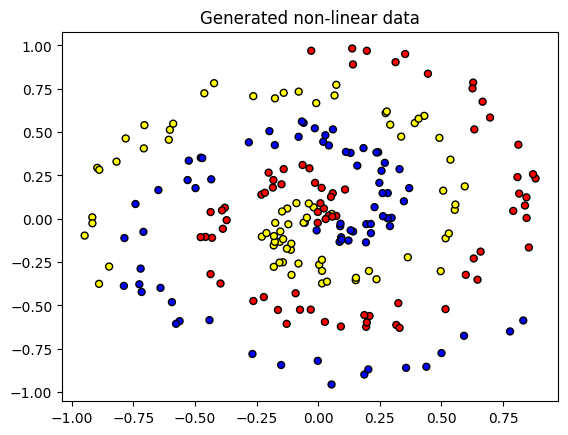

In [35]:
# Visualize data
plt.title("Generated non-linear data")
colors = {0: "red", 1: "yellow", 2: "blue"}
plt.scatter(X_val[:, 0], X_val[:, 1], c=[colors[_y] for _y in predictions], edgecolors="k", s=25)
plt.show()

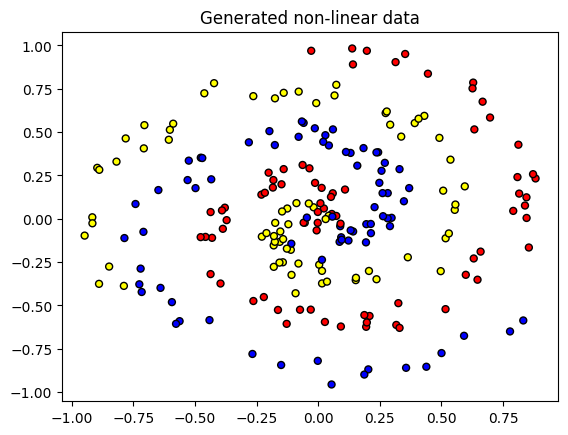

In [36]:
# Visualize data
plt.title("Generated non-linear data")
colors = {0: "red", 1: "yellow", 2: "blue"}
plt.scatter(X_val[:, 0], X_val[:, 1], c=[colors[_y] for _y in y_val], edgecolors="k", s=25)
plt.show()

In [37]:
# Quick check for accuracy
knn.score(X_val,y_val)

0.9466666666666667

### Learning curves loop

we compute accuracy for a range of n_neighbors from 1 to 25 and record both training and validation accuracy to plot learning curves

In [49]:
train_accuracy = {}
validation_accuracy = {}

In [50]:
neighbors = np.arange(1,26)
neighbors

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25])

In [52]:
for i in neighbors:
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_val)
    train_accuracy[i] = knn.score(X_train,y_train)
    validation_accuracy[i] = knn.score(X_val,y_val)

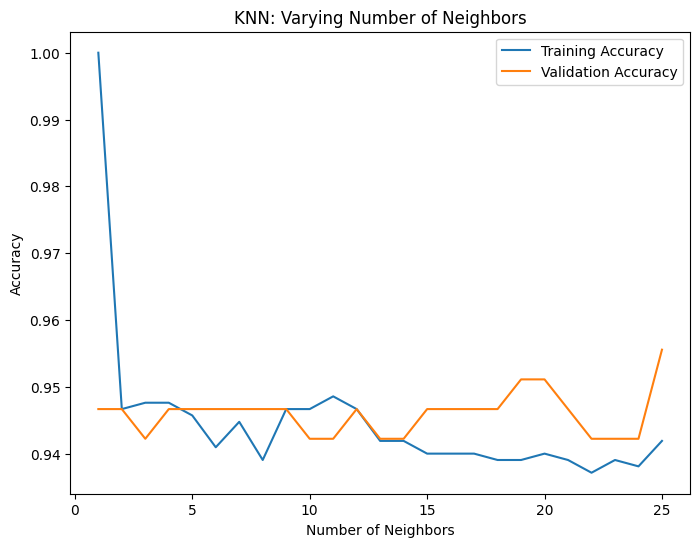

In [53]:
# Plotting some learning curves -- in practice the accuracy is always really high
plt.figure(figsize=(8, 6))
plt.title("KNN: Varying Number of Neighbors")
plt.plot(neighbors, train_accuracy.values(), label="Training Accuracy")
plt.plot(neighbors, validation_accuracy.values(), label="Validation Accuracy")
plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()

### Pick a final model and score on the test set

In [59]:
# Pick n = 5 as the final model
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)
test_predictions = knn.predict(X_test)
test_predictions

array([1, 1, 0, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1,
       2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 1, 2, 1, 0, 2, 1, 2, 2, 1,
       0, 1, 0, 0, 0, 1, 1, 2, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 2, 2, 0, 0, 0, 0, 1,
       1, 2, 2, 2, 2, 1, 2, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 0, 1, 2,
       1, 0, 0, 0, 2, 0, 0, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 0, 0, 1, 1, 0,
       2, 2, 1, 2, 0, 1, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 1, 0, 2, 0,
       1, 0, 1, 2, 0, 2, 2, 2, 2, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1,
       0, 2, 2, 1, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 1, 2,
       1, 2, 1, 2, 2])

In [60]:
knn.score(X_test,y_test)

0.9466666666666667

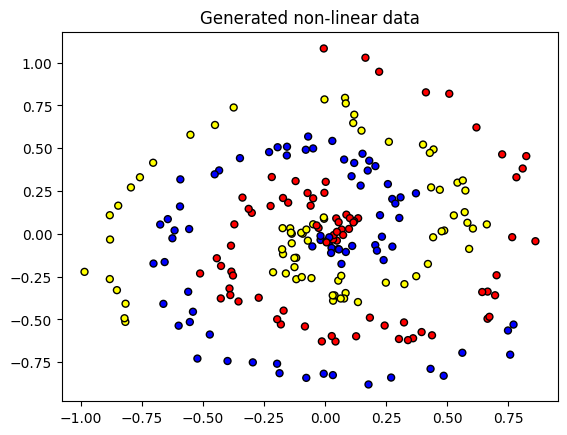

In [61]:
# Visualize predicted classes
plt.title("Generated non-linear data")
colors = {0: "red", 1: "yellow", 2: "blue"}
plt.scatter(X_test[:, 0], X_test[:, 1], c=[colors[_y] for _y in test_predictions], edgecolors="k", s=25)
plt.show()

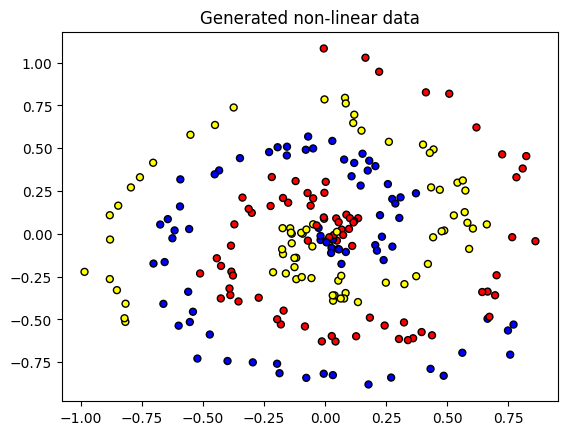

In [63]:
# Visualize actual classes
plt.title("Generated non-linear data")
colors = {0: "red", 1: "yellow", 2: "blue"}
plt.scatter(X_test[:, 0], X_test[:, 1], c=[colors[_y] for _y in y_test], edgecolors="k", s=25)
plt.show()